<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

<font size=6>**Welcome to the Lensing Challenge!**</font>

<div style="border-left: 5px solid #2878b5; padding: 12px 20px; margin: 20px 0;">
  <p style="font-size: 18px; margin: 0 0 8px;">
    <strong>TALES School II</strong><br>
    Hands-on workshop on machine learning applications to astrophysics
  </p>
  <p style="color: #666; margin: 0;">
    September 13–18, 2026 · Petnica Science Center, Serbia
  </p>
</div>

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

This Hackathon is a chance to put your astronomy, statistics, and coding skills into practice, work together, and try out new ideas.

Your challenge is to **estimate time delays** from the supplied lensed light curves — Explore the data, develop your method, and collect your predictions.

Start with a simple approach, compare ideas with your teammates, and build from there. 

&emsp;&emsp; Happy hacking!

</div>

# Data

## The Generative Process

There are quite diverse components that go into generating mock quasar light curves. We briefly describe the most important ones below, noting that each of the presented models and approximations could be an oversimplification of how nature behaves in reality.

<img src="images/flowchart.png" width=750 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=750><center><br>
    Figure 1. Flowchart of the lensed quasar mock light curve generative process described in this section<br>
    (<i>From <a href="https://ui.adsabs.harvard.edu/abs/2022MNRAS.511.4417V/abstract" target="_blank">Vernardos 2022</a></i>).
<br></center></td></tr></table>


### The lens configuration (macromodel)

The first step describes the properties of the lens and the source that will produce the lensing effect.
We need to assume a mass distribution for the lens which will be responsible for deflecting the incoming light rays from the source.

Although galaxies in nature can be complex conglomerates of stars, gas, and dark matter, in practice, it turns out that an **elliptical mass distribution** with varying slope can describe lensing observables quite well ([Shajib et al. 2024](https://ui.adsabs.harvard.edu/abs/2024SSRv..220...87S/abstract)).
If the quality of the data is very high, then higher order moments in the mass distribution, such as multipoles, can also be justified (see [O'Riordan et al. 2025](https://ui.adsabs.harvard.edu/abs/2025A%26A...694A.145O/abstract) for an exquisite NGC lens discovered by Euclid).
Here we assume the **Singular Isothermal Ellipsoid** distribution ([Kassiola & Kovner 1993](https://ui.adsabs.harvard.edu/abs/1993ApJ...417..450K/abstract)), together with external shear that mimicks the shearing deflections due to outlying mass of neighbouring galaxies in the lens plane or along the line of sight.

The position of the quasar source with respect to the lens' mass distribution will give rise either to 2 or 4 multiple images (there is a known lensed quasar with 6 images, but this case is a ''Einstein zig-zag'' involving a second lens along the line of sight).
For very close alignment we get 4 images in one of the following configurations:
- a **cross** (symmetric, almost perfect alignment between lens and source)
- a **cusp** (3 bright images close to each other and a dim one further away)
- a **fold** (2 bright images close to each other and 2 less bright ones further away)
If the quasar lies further away from the optical axis then we get only 2 images (a double).
We included all of these examples in the simulated mocks.

It should be noted that once the macro-scopic configuration of the lens is set, then the time-delays are fixed.


### Intrinsic variability

A successful model to describe how quasar brightness varies intrinsically is the **Damped Random Walk** ([MacLeod et al. 2010](https://ui.adsabs.harvard.edu/abs/2010ApJ...721.1014M/abstract)).
This is a stochastic process with a well-defined mean for sufficiently long time scales.
There are robust empirical relations from the literature that provide the **parameters** of this model based on the:
- **quasar luminosity**
- **redshift**, and
- **observed wavelength**.
  
Here we randomly sample these parameters within typical observed ranges and produce realizations of quasar intrisic light curves lasting more than 10 years.


### Instrumental effects — date and noise

Monitoring quasars requires regular observations separated by no-more than **a few days**.
Each facility has different time, resource, and geographic constraints, leading to **irregularly sampled** data points.

In addition, the sensitivity of each **instrument** and its optical system specifications determine the **uncertainty** in the obtained measurements of the flux of each lensed quasar image.
Here we adopt the [LSST Data Products 0.2](https://arxiv.org/abs/2010.05926) simulations (see also [here](https://dp0-2.lsst.io/data-products-dp0-2/)).
This catalogue returns the visits at specific coordinates on the sky, from which we obtain the dates of observation and the sky brightness, seeing, exposure time, airmass, etc, which we use to infer the measured flux uncertainty (see equations 4, 5, and 6 in [Ivezic et al. 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...873..111I/abstract)).

Because **LSST** photometry is very precise (0.005 mag of systematic uncertainty!), we **artificially inflate** the error bars by a factor of **10** in order to be more lenient with the challenge submissions.
Also, because the DP0.2 simulated observations are for a 5 year period, which may be to short and sparse in the **$i$-band** (_which we selected to be consistent with the intrinsic Damped Random Walk model_), we **artificially pad them to reach 10 years**.


### Microlensing

We have included microlensing effects in our simulated lensed quasars using the recipe provided by [Vernardos (2022)](https://ui.adsabs.harvard.edu/abs/2022MNRAS.511.4417V/abstract), where you can find more detailed descriptions of the components of mock generation described above.
For an in-depth review of quasar microlensing see [Vernardos et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024SSRv..220...14V/abstract).


## Light Curves

Let us have a look at an example of the data you will receive.

Each system can be either a **doubly** or **quadruply** lensed quasar, resulting in either **2** or **4** light curves.<br>
(_one for each image of the quasar_).

The animation below illustrates how repeated observations of a lensed system lead to a **time series** of **flux** values.

<details style="border-left: 4px solid #2196F3; padding: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">
  <summary style="cursor: pointer;"><b>[Details]</b></summary>

In practice, a single pointing of a telescope will result in adding a point in each of the light curves as long as one can perform accurate photometry by deblending the multiple images of the quasar from each other and from the lens galaxy light.

This can actually be quite challenging; [Neira et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv250416249N/abstract) present a challenge to obtain accurate light curves from a set of images with varying seeing, point spread function (PSF), and, most importantly, overlap of the lens and lensed quasar flux.

Once photometry is obtained, then each light curve is simply a series of flux measurements (_with uncertainties_) over time. 

</details>

In [1]:
from IPython.display import Video, display
display(Video("videos/obtaining_light_curves.mp4", embed=False, width=800))

We provide the light curve data for each system in a `.json` file, which is basically just a **list** containing either 2 or 4 light curves.

Each light curve entry in this list is a **dictionary** containing:
- the *flux* ("`signal`", in mag in some arbitrary optical filter),
- the *timestamp* ("`time`", in days, from some arbitrary reference), and
- the *error* on the flux ("`dsingal`", same units as the flux).

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<b>WARNING:</b> The order of the light curves in the `.json` file is important and should be **preserved**.

It is assumed that:
- 1st curve in the `.json` file $\rightarrow$ label: 0
- 2nd curve in the `.json` file $\rightarrow$ label: 1
- 3rd curve in the `.json` file $\rightarrow$ label: 2
- 4th curve in the `.json` file $\rightarrow$ label: 3

</div>

Let's **read** and **plot** such a file.

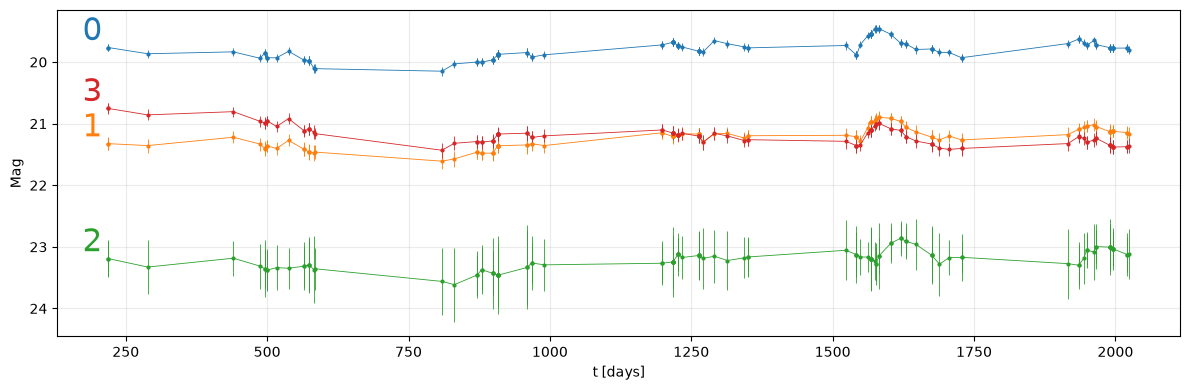

Light curve label: '0'


,dsignal,signal,time
0,0.063561,19.764578,218.936057
1,0.063794,19.764643,218.949950
2,0.066091,19.865728,288.799591


Light curve label: '1'


,dsignal,signal,time
0,0.099870,21.325666,218.936057
1,0.102438,21.324967,218.949950
2,0.113447,21.356218,288.799591


Light curve label: '2'


,dsignal,signal,time
0,0.277628,23.189840,218.936057
1,0.305606,23.189929,218.949950
2,0.439673,23.327866,288.799591


Light curve label: '3'


,dsignal,signal,time
0,0.081232,20.753428,218.936057
1,0.082350,20.753308,218.949950
2,0.090105,20.857857,288.799591


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt


def read_light_curves(path_to_file):
    """Load light curves from a JSON file into a dictionary of DataFrames.

    Parameters
    ----------
    path_to_file : str or path-like
        Path to a JSON file containing a list of light-curve dictionaries.
        Each dictionary contains equal-length arrays: ``time`` (days),
        ``signal`` (magnitudes), and ``dsignal`` (signal uncertainties).

    Returns
    -------
    dict[int, pandas.DataFrame]
        Light curves indexed by their zero-based position in the file.
        Each DataFrame has one row per observation and preserves the
        original column names and values.
    """

    with open(path_to_file, encoding="utf-8") as fh:
        curves = json.load(fh)

    df_curves = {}
    for i, curve in enumerate(curves):
        df_curves[i] = pd.DataFrame(curve)

    return df_curves


def plot_light_curves(dict_of_lcs):
    """Plot light curves previously read from a JSON file.

    Parameters
    ----------
    dict_of_lcs: dict[int, pandas.DataFrame]
        Light curves indexed by their zero-based position in the file.
        Each DataFrame has one row per observation and preserves the
        original column names and values. This can be the output of the 
        'read_light_curves' function defined above.
        
    Returns
    -------
    A matplotlib plot.
    """
        
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for i, df_curve in dict_of_lcs.items():
        #ax.plot(df_curve["time"], df_curve["signal"], ".-", ms=3, lw=0.6)
        ax.errorbar(df_curve["time"],
                    df_curve["signal"],
                    yerr=df_curve["dsignal"],
                    lw=0.6,
                    marker='o',
                    ms=2)
        ax.text(df_curve["time"][0]-10,
                df_curve["signal"][0],
                i,
                horizontalalignment='right',
                verticalalignment='bottom',
                fontsize=22,
                color=plt.gca().lines[-1].get_color())
    
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.set(xlabel="t [days]", ylabel="Mag")
    plt.tight_layout()
    plt.show()
    
#LC_FILE = "mock_data/pVyXdqa4j6_light_curves.json"
LC_FILE = "mock_data/Y0136jVQ06.json"

lcs = read_light_curves(LC_FILE)

plot_light_curves(lcs)

# Display the light curves directly from the dict of pandas dataframes
for i, df_curve in lcs.items():
    print( "Light curve label: '{label}'".format(label=i) )
    display(df_curve.head(3))

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

# The Challenge
    
## Objective

For every lensed quasar in the **Test** data, estimate the time delays between each **pair** of lensed light curves.

## Data

You will receive:
- **Training** data $\rightarrow$ The light curves with ground-truth $\Delta t$
- **Test** data $\rightarrow$ The light curves for which you will estimate $\Delta t$

> _NOTE: These lensed quasars may be either quads or doubles, so you may have 2 or 4 light curves in each file._

The time-delay between each pair of light curves has to be labelled using the labels of the light curves.

- _If it is a double, then you will have to report only one time delay: $\Delta t_{01}$ (between light curves '0' and '1')_
- _For quads, there are only three truly independent time-delays. You will need to report these three values with **respect to the leading image** (first in the .json file), that is: $\Delta t_{01}$, $\Delta t_{02}$ and $\Delta t_{03}$._


<u>**Training data**</u>

- Light curves (`.json` files), one for each lens.

- A *master* catalog (`train.csv`) with the following information:

$$
\begin{array}{ll}
\text{Column name} & \text{Description} \\
\hline
\textbf{id} & \text{An alphanumeric id to distinguish each lens. The corresponding light curves will be in a file named `<id>.json`.} \\
\textbf{flag} & \text{An integer indicating whether the lens is a double (2) or a quad (4).} \\
\textbf{01} & \text{The true time delay (in days) between light curves '0' and '1'.} \\
\textbf{02} & \text{The true time delay (in days) between light curves '0' and '2'. For a double lens, this will be set to 'NA'.} \\
\textbf{03} & \text{The true time delay (in days) between light curves '0' and '3'. For a double lens, this will be set to 'NA'.} \\
\hline
\end{array}
$$


➜] Get the light curves: [training data](https://www.dropbox.com/scl/fo/jobj0cgewl2ndcnqu3tyq/AD9GIrORcPgWRgBrorZ81Ss?rlkey=sfrvk9wal85r2hlcbyg9r5mvg&st=twhgires&dl=0)
    
➜] Get the labels: [train.csv](../data/train.csv)

    
<u>**Test data**</u>

- Light curves (`.json` files), one for each lens.
    
- A *master* catalog (`test.csv`), with the same structure as above.

    This catalogue comes pre-filled with "NA" values for every $\Delta t$: these are the values you need to predict! 

➜] Get the light curves: [test data](https://www.dropbox.com/scl/fo/msktuznhwd4ax6j8j323u/AP3ZibMF5BwKSkaoZJ5VnDc?rlkey=3c600jp7xyq5tlfypq70mbcrf&st=uf3ulpnw&dl=0)
    
➜] Get the labels: [test.csv](../data/test.csv)

## Deliverable

You will need to fill-in the predictions for $\Delta t$ in `test.csv` $\rightarrow$ submit it as `results_<your-team's_name>.csv`.

> _Watch out! Double systems only need predictions for column `01`, you can leave the rest to "NA"._


## Assessment

The winning team will be the one <u>minimizing</u> the **Root Mean Square Error** (**RMSE**) between the predictions and the ground truth (_averaged across all systems and all light curves_).
    
You can use the provided function below, `score`, to validate your progress: this will be the _exact_ function used to assess your submission.

</div>

# Score

This section briefly shows how to assess your results with the provided **scoring function**, `score`:


In [12]:
# You do not know this for the test set
import pandas as pd

df_truth = pd.read_csv('mock_data/truth.csv')
display(df_truth)
# - first row is a double
# - second is a quad

,id,flag,01,02,03
0,BxXRI85hXI,2,-30.6713,NaN,NaN
1,mmLwyNLlhe,2,39.3822,NaN,NaN
2,mSqI1htyP3,4,30.2132,49.8275,27.0755


In [21]:
# You submit the corresponding results
df_results = pd.read_csv('mock_data/results.csv')

display(df_results)
# reply for system "mSqI1htyP3" is malformed (02 missing; it will be accepted but ignored by the scoring function)

,id,flag,01,02,03
0,BxXRI85hXI,2,-29.0,NaN,NaN
1,mmLwyNLlhe,2,39.0,Na,NA
2,mSqI1htyP3,4,29.0,NaN,29.0


In [22]:
import numpy as np
import pandas as pd

df_truth   = pd.read_csv("mock_data/truth.csv")
df_results = pd.read_csv("mock_data/results.csv")

def score(df_results, df_truth):
    """Return the root mean squared error (RMSE) in days.

    Compute the square root of the average squared error across all matched
    IDs and all three time-delay columns. Skip pairs where either value is
    missing ("NA", "NaN", or np.nan). Return NaN if no valid pairs remain.

    Parameters
    ----------
    df_results, df_truth : pandas.DataFrame
        Predicted and reference values, respectively. Each must contain
        ``ID``, ``01``, ``02``, and ``03``.
        Only IDs present in both frames are scored (inner join).

    Returns
    -------
    float
        Square root of the mean squared difference across all valid delay
        pairs, with equal weight per pair. Lower is better; zero is exact.
        Returns NaN if no valid pairs remain.

    Notes
    -----
    Numeric strings are accepted. Missing values (including the strings
    "NA" and "NaN", and np.nan) and other nonnumeric values are coerced
    to NaN. A pair is excluded if either value is missing.
    Displays the first five comparison rows with signed errors.
    """

    df_comparison = df_truth.merge(
        df_results, on="id", suffixes=("_truth", "_result")
    )

    for col in ["01", "02", "03"]:
        truth = pd.to_numeric(df_comparison[f"{col}_truth"], errors="coerce")
        result = pd.to_numeric(df_comparison[f"{col}_result"], errors="coerce")
        df_comparison[f"{col}_error"] = result - truth

    display(df_comparison.head())

    # Pool all valid errors before taking the root mean square.
    errors = df_comparison[[f"{col}_error" for col in [
        "01", "02", "03"
    ]]].stack()
    rmse = float(np.sqrt(errors.pow(2).mean()))

    return rmse

print("Your RMSE score: %.2g" % score(df_results, df_truth))

,id,flag_truth,01_truth,02_truth,03_truth,flag_result,01_result,02_result,03_result,01_error,02_error,03_error
0,BxXRI85hXI,2,-30.6713,NaN,NaN,2,-29.0,NaN,NaN,1.6713,NaN,NaN
1,mmLwyNLlhe,2,39.3822,NaN,NaN,2,39.0,Na,NA,-0.3822,NaN,NaN
2,mSqI1htyP3,4,30.2132,49.8275,27.0755,4,29.0,NaN,29.0,-1.2132,NaN,1.9245


Your RMSE score: 1.4


In [ ]:
#EOF